In [47]:
import os
import pickle
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt



In [12]:
results_path = "results/beta_values_from_mean_pooling_code.pkl"
with open(results_path, 'rb') as f:
    results_dict = pickle.load(f)


In [ ]:
# My results from ridge regression have the following structure
'''
participant : {
    ROI : {
        model : {
            layer : mean r2 value
        }
    }
}
'''

### ROI Performance
I'd like to analyze how well each Region of Interest "aligns" with each layer of the models. I should report findings separately for each model, but aggregate across participants, ROIs, and layers.

iterate over participants, aggregate by ROI and layer

In [ ]:
roi_findings = {}
for participant, roi_dict in results_dict.items():
    for roi, model_dict in roi_dict.items():
        # model_dict, layer
        # roi_findings keys should be rois, with values being dictionaries for each model, and performance results therein
        for model, layer_dict in model_dict.items():
            
            if roi not in roi_findings.keys():
                roi_findings[roi] = {}

            if model not in roi_findings[roi].keys():
                roi_findings[roi][model] = list(layer_dict.values())
            else:
                roi_findings[roi][model].extend(list(layer_dict.values()))


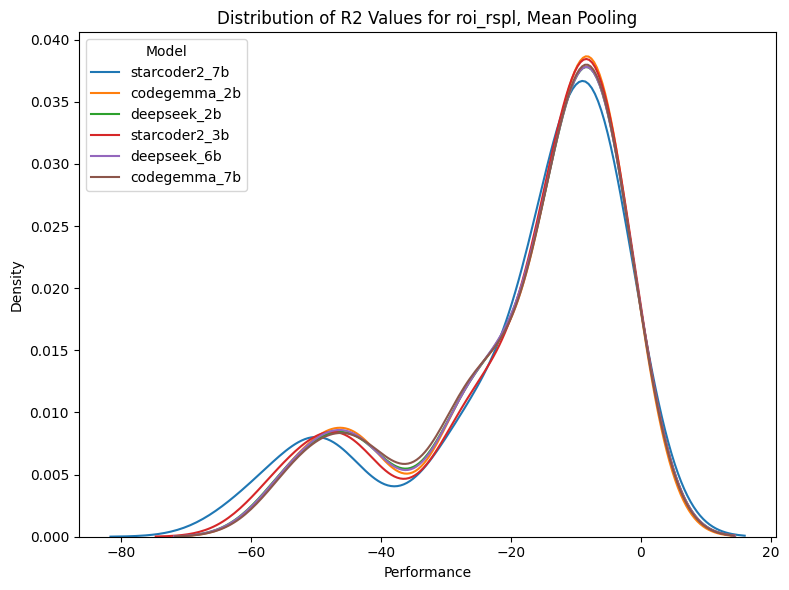

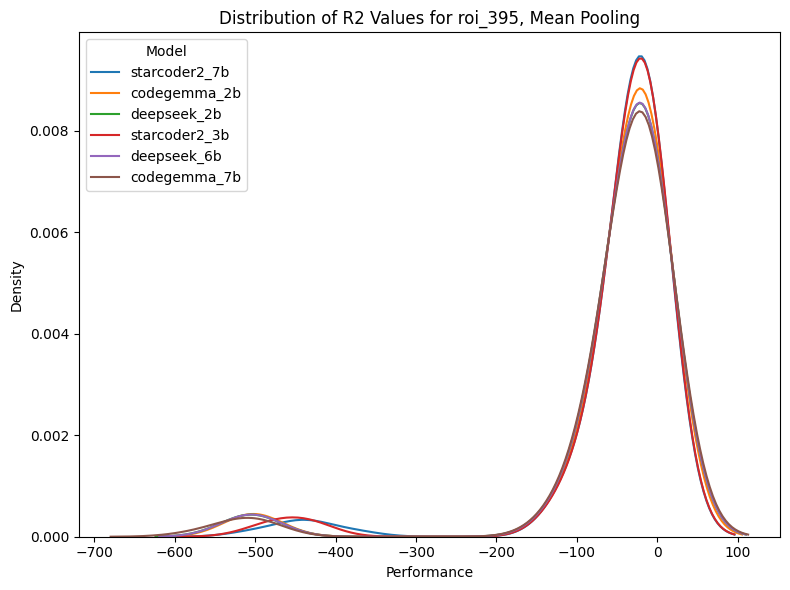

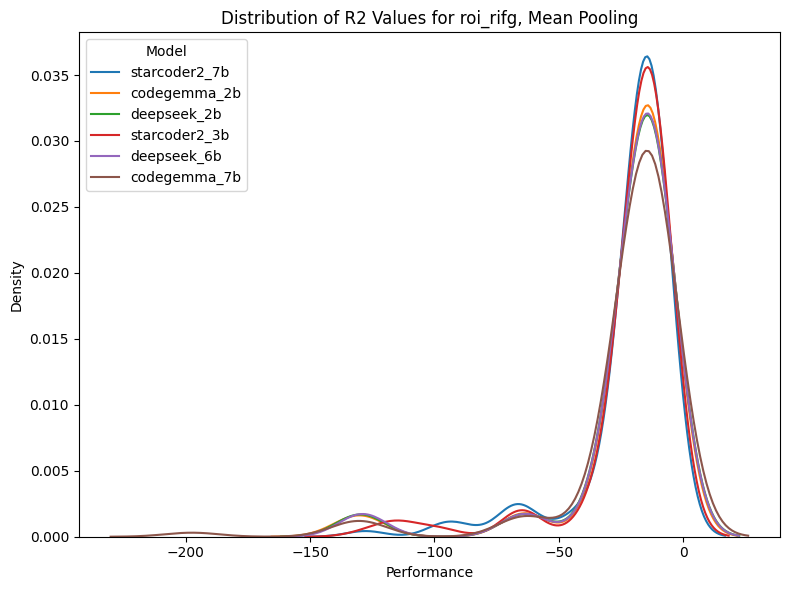

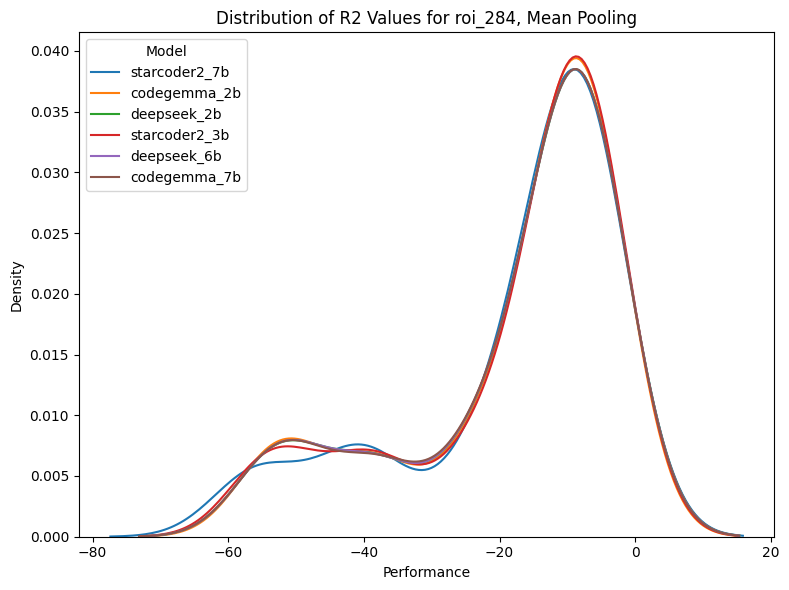

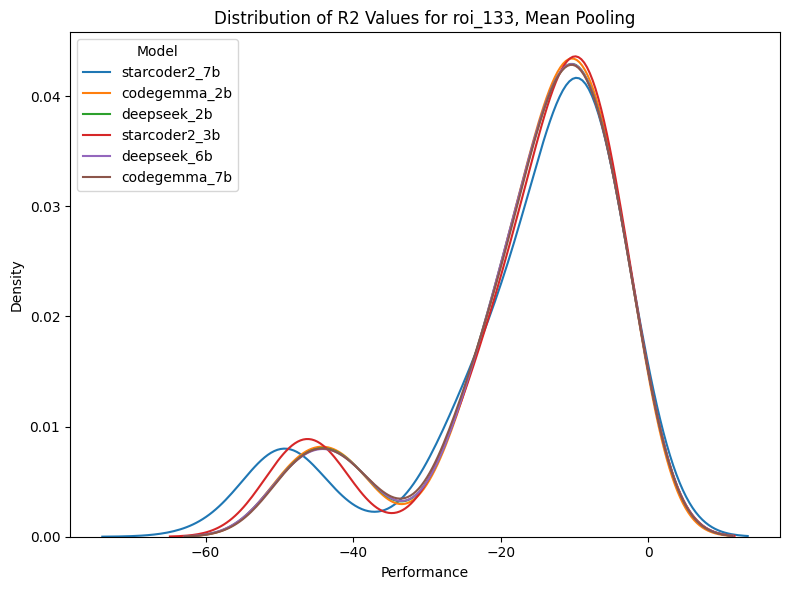

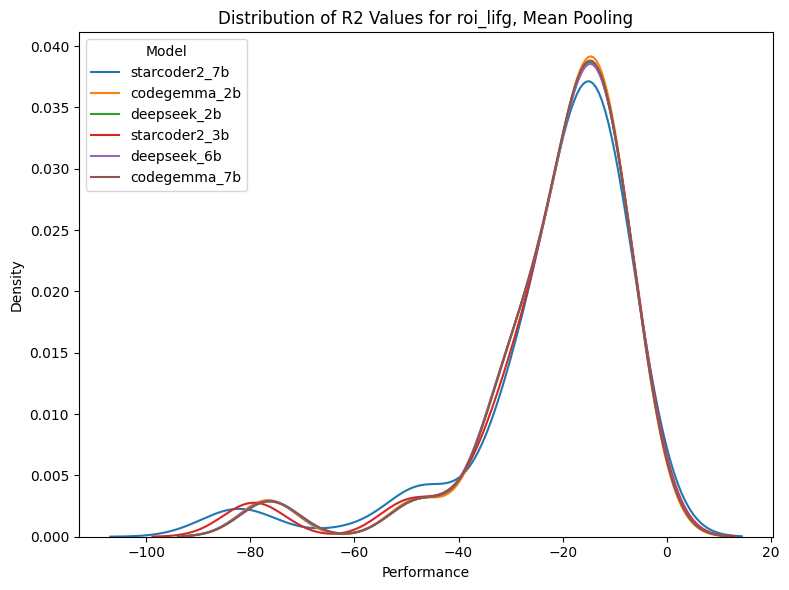

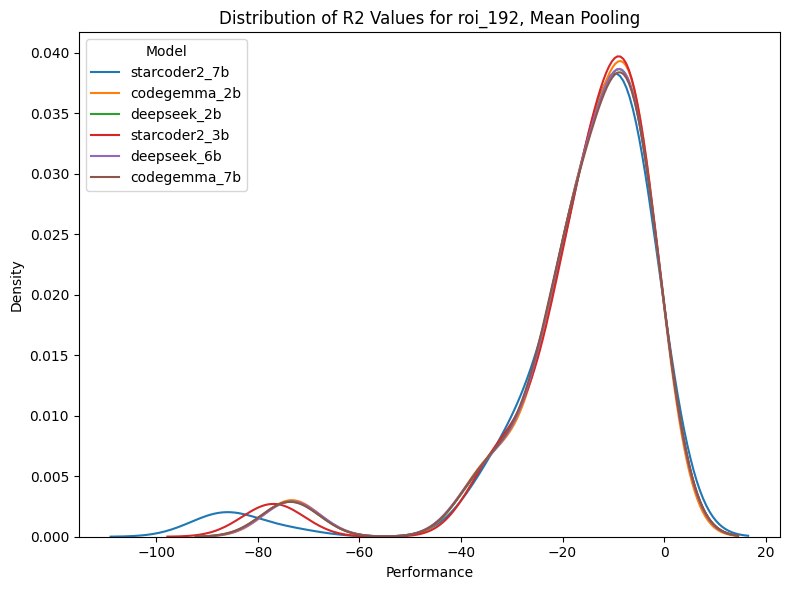

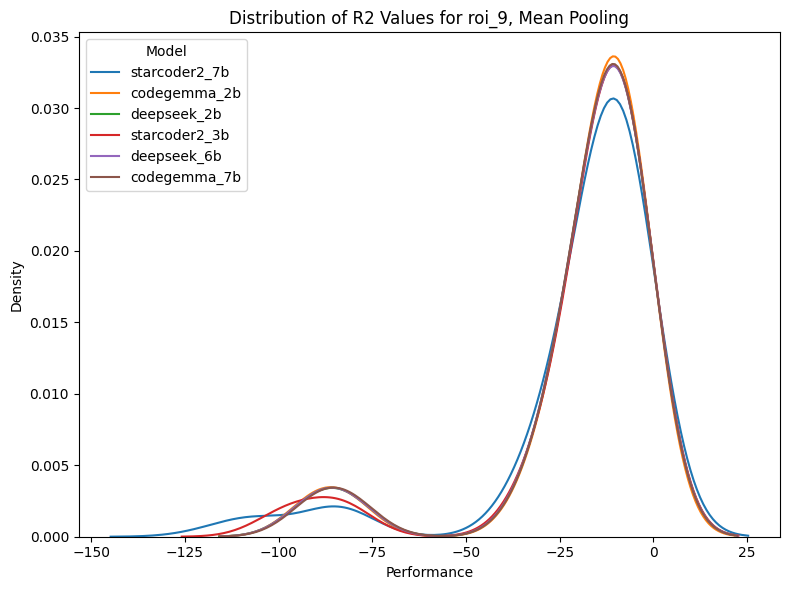

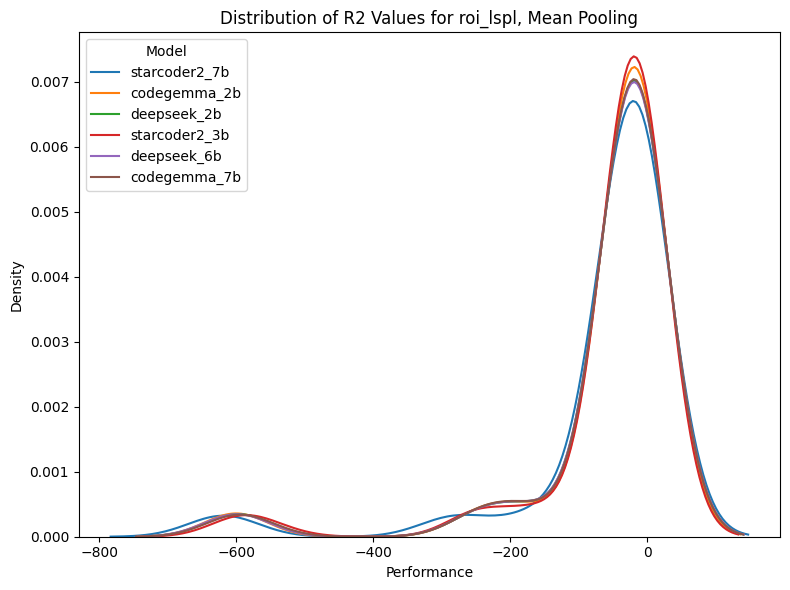

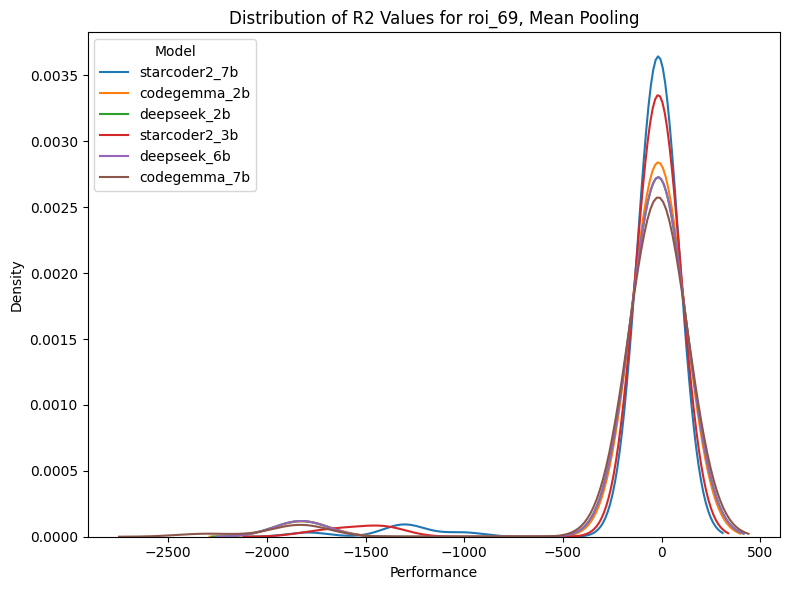

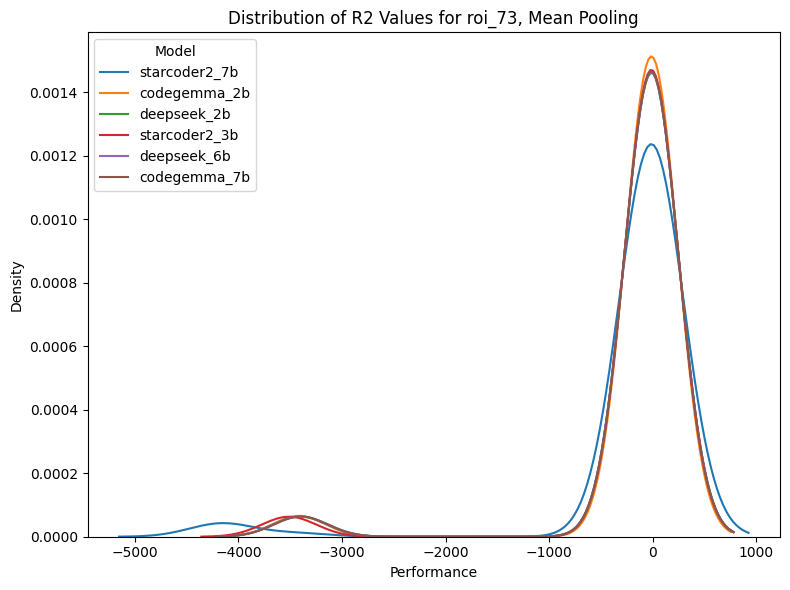

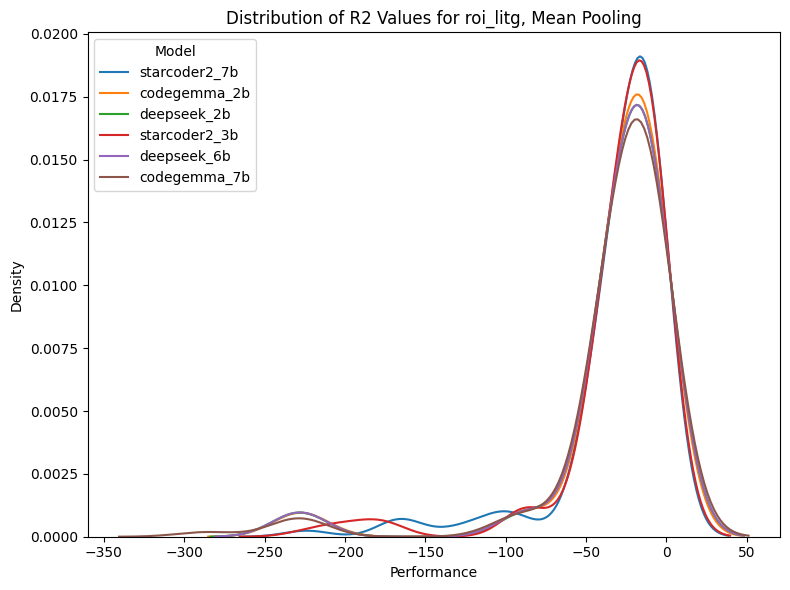

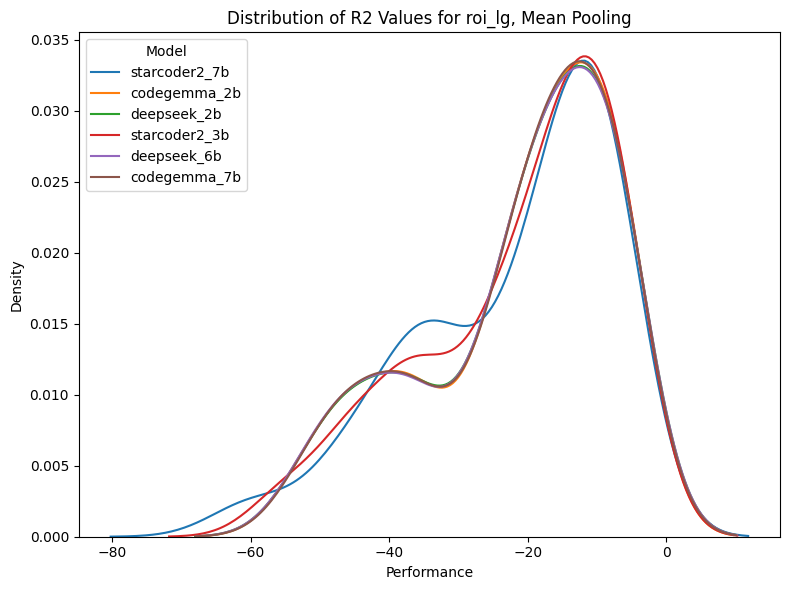

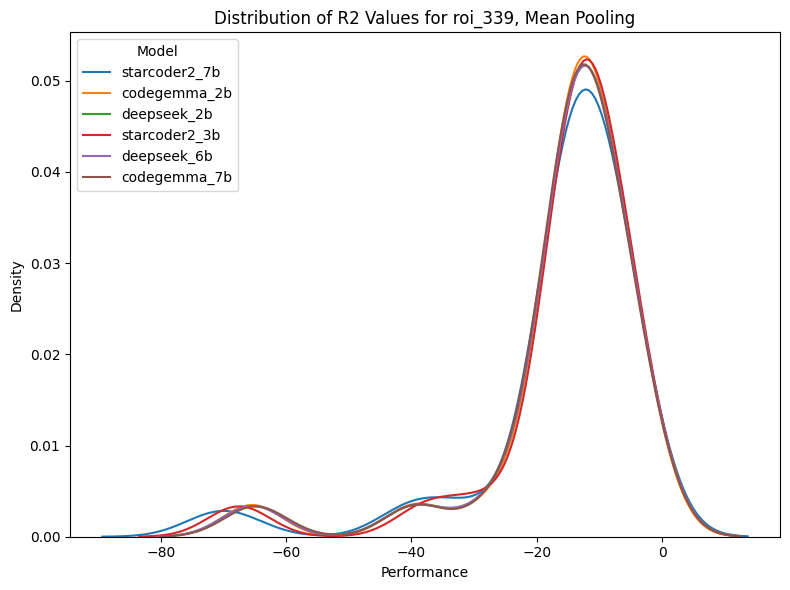

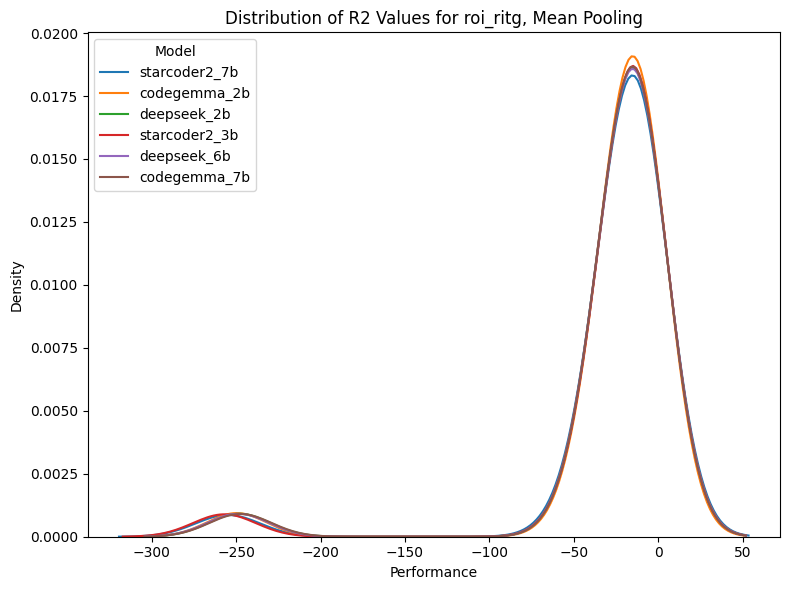

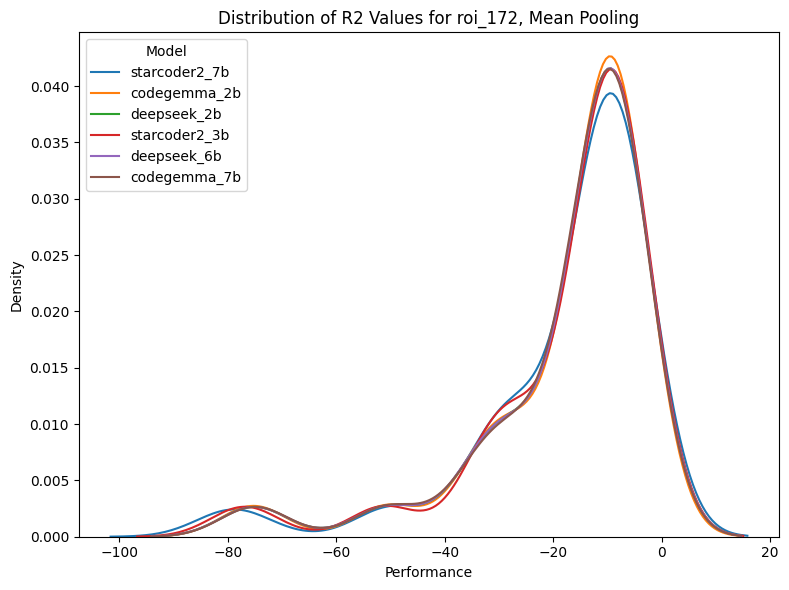

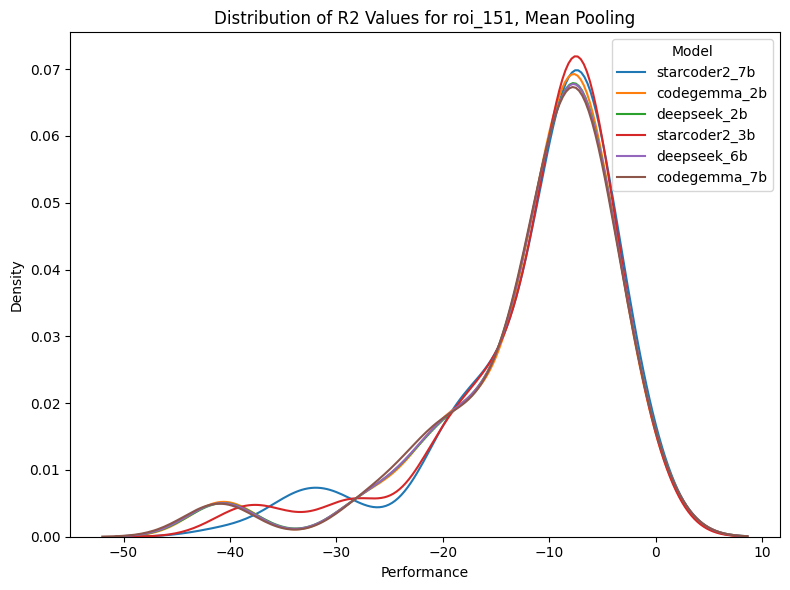

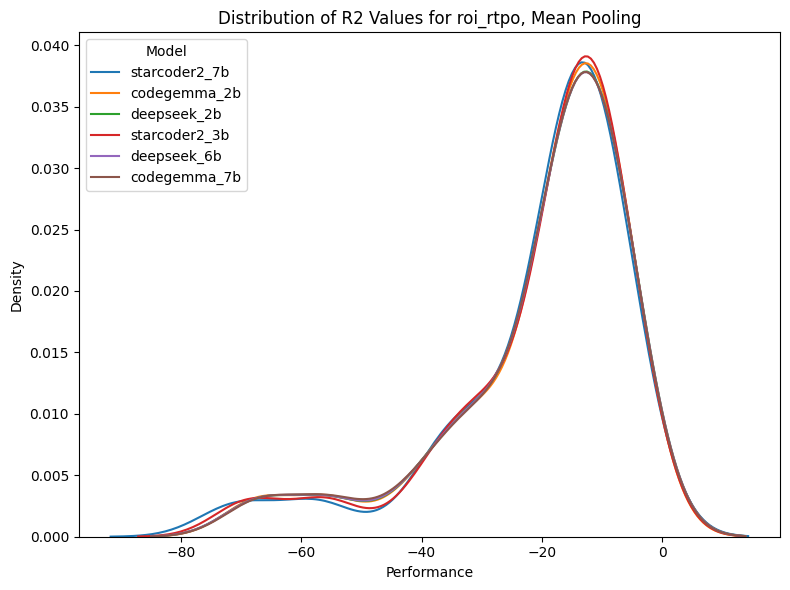

In [32]:
# Make separate plot for each ROI
for roi, model_data in roi_findings.items():
    plt.figure(figsize=(8, 6))
    
    # Plot each model's distribution
    for model, values in model_data.items():
        sns.kdeplot(values, label=model, fill=False)  # use sns.histplot if you prefer
    
    plt.title(f"Distribution of R2 Values for {roi}, Mean Pooling")
    plt.xlabel("Performance")
    plt.ylabel("Density")
    plt.legend(title="Model")
    plt.tight_layout()
    plt.show()

### Expertise
To compare model performance based on years of coding experience, I should have a dictionary with 
novices and experts as keys, then dictionaries as values where the keys are still models, and the values are aggregated across participants and layers

In [40]:
expertise_findings = {
    'novices' : {},
    'experts' : {}
}

expertise_roi_findings = {
    'novices' : {},
    'experts' : {}
}

experts = [ '112', '141', '105', '109', '118', '122', '129', '138', '143', '147', '101', '102', '108', '111', '201']

not_labeled = ['117', '204']

for participant, roi_dict in results_dict.items():
    if participant in experts:
        group = 'experts'
    elif participant not in experts and participant not in not_labeled:
        group = 'novices'
    else:
        continue

    for roi, model_dict in roi_dict.items():
        for model, layer_dict in model_dict.items():

            if model not in expertise_findings[group].keys():
                expertise_findings[group][model] = list(layer_dict.values())
            else:
                expertise_findings[group][model].extend(list(layer_dict.values()))

            if model not in expertise_roi_findings[group].keys():
                expertise_roi_findings[group][model] = {}
                
            if roi not in expertise_roi_findings[group][model].keys():
                expertise_roi_findings[group][model][roi] = list(layer_dict.values())
            else:
                expertise_roi_findings[group][model][roi].extend(list(layer_dict.values()))


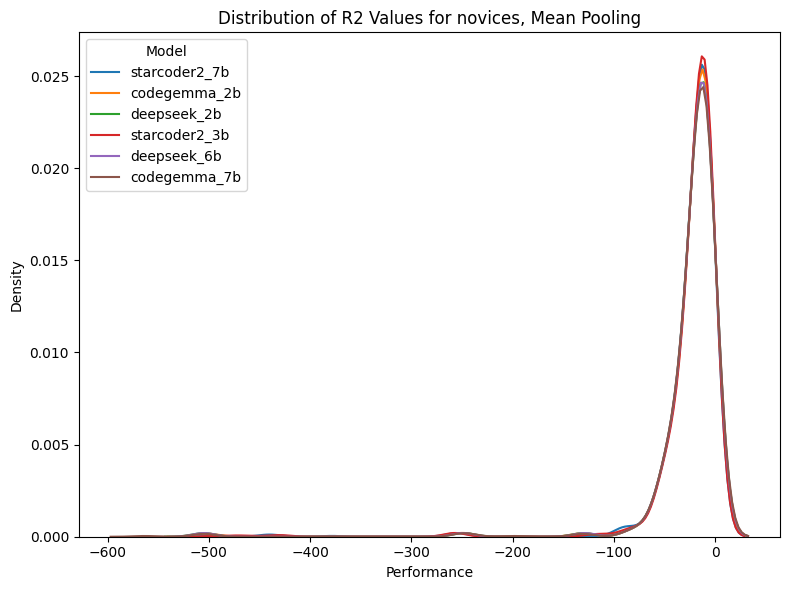

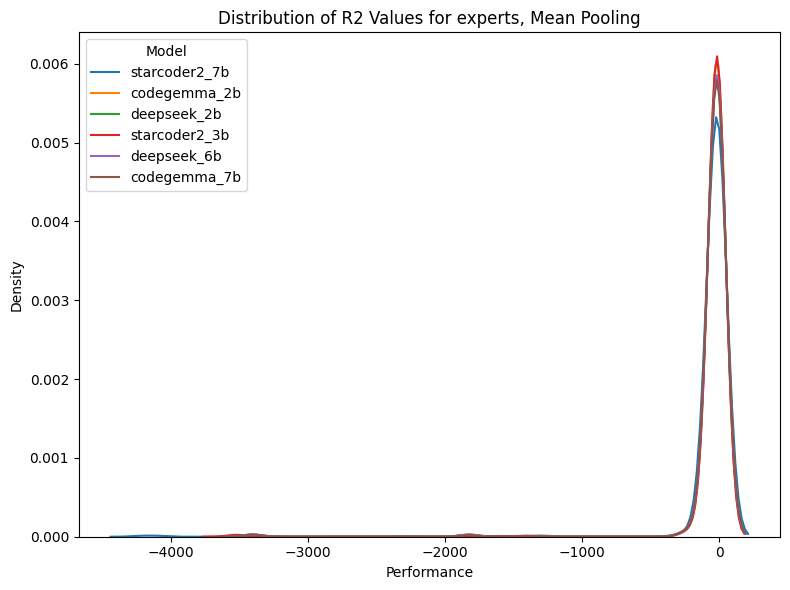

In [37]:
# Make separate plot for each ROI
for group, model_data in expertise_findings.items():
    plt.figure(figsize=(8, 6))
    
    # Plot each model's distribution
    for model, values in model_data.items():
        sns.kdeplot(values, label=model, fill=False)  # use sns.histplot if you prefer
    
    plt.title(f"Distribution of R2 Values for {group}, Mean Pooling")
    plt.xlabel("Performance")
    plt.ylabel("Density")
    plt.legend(title="Model")
    plt.tight_layout()
    plt.show()

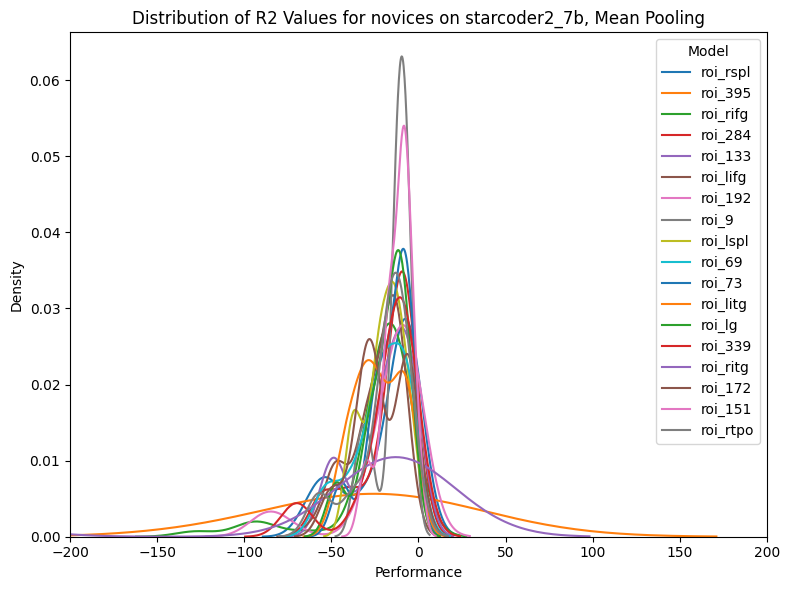

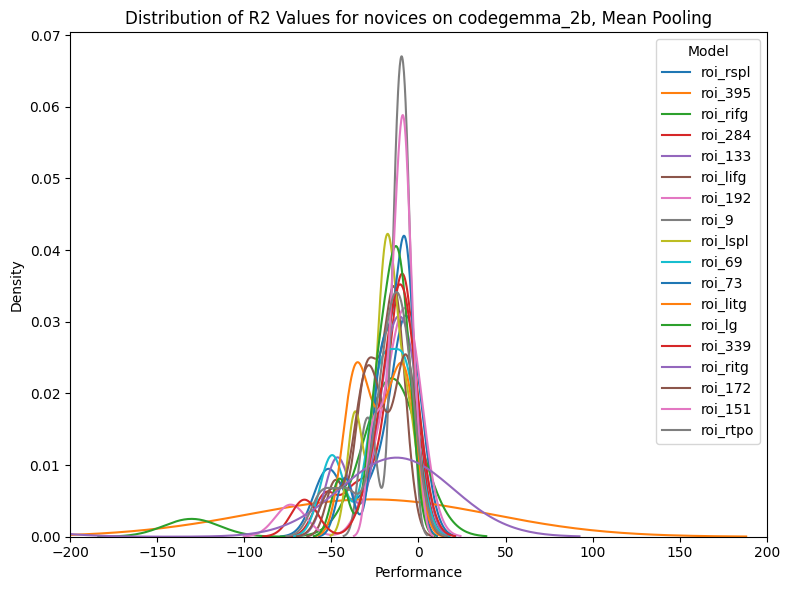

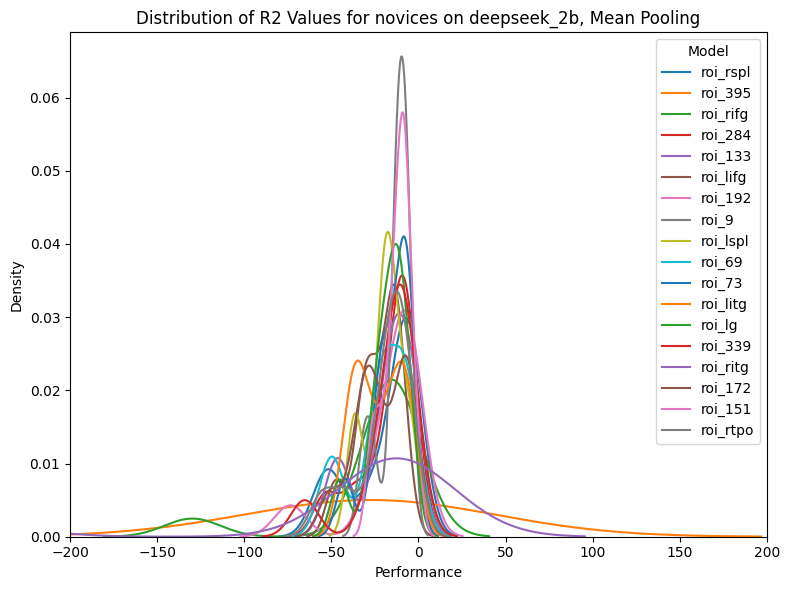

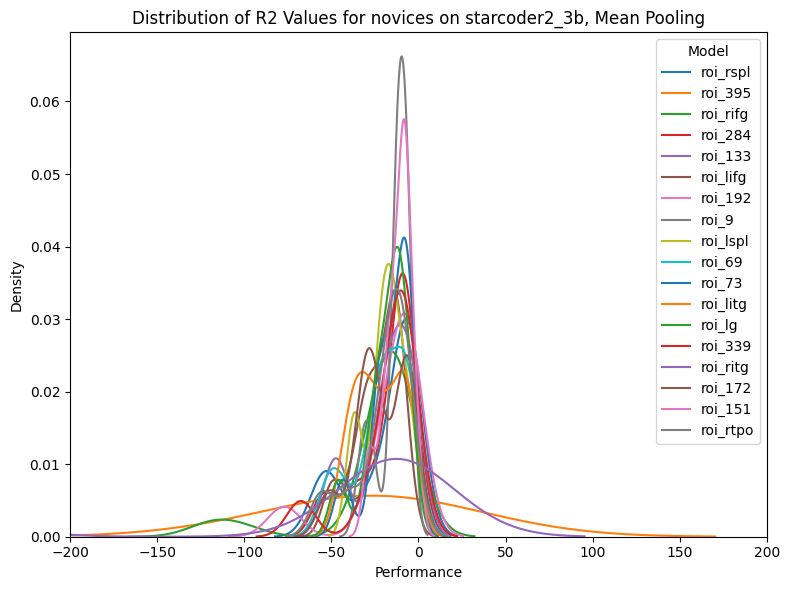

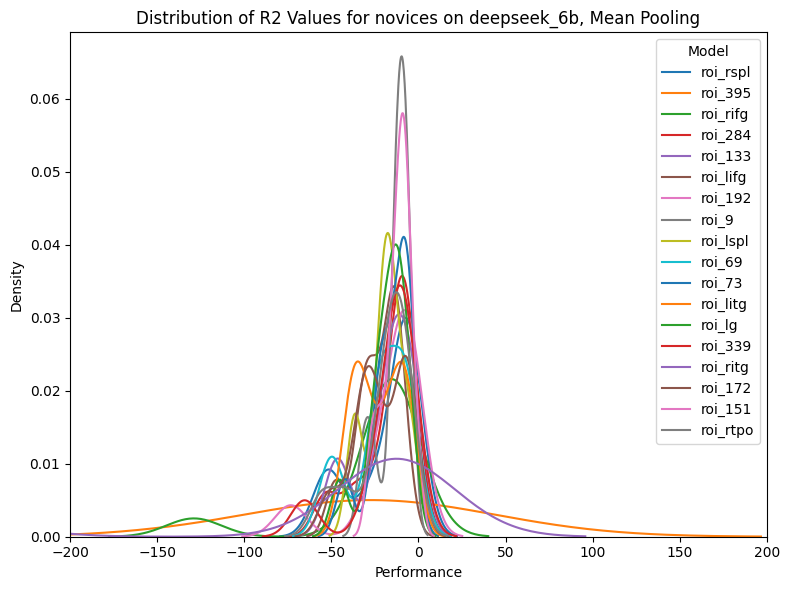

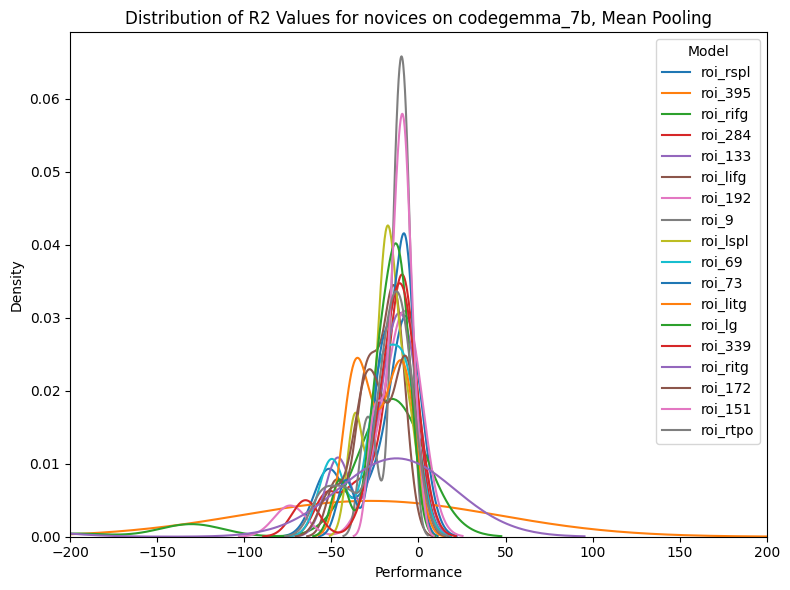

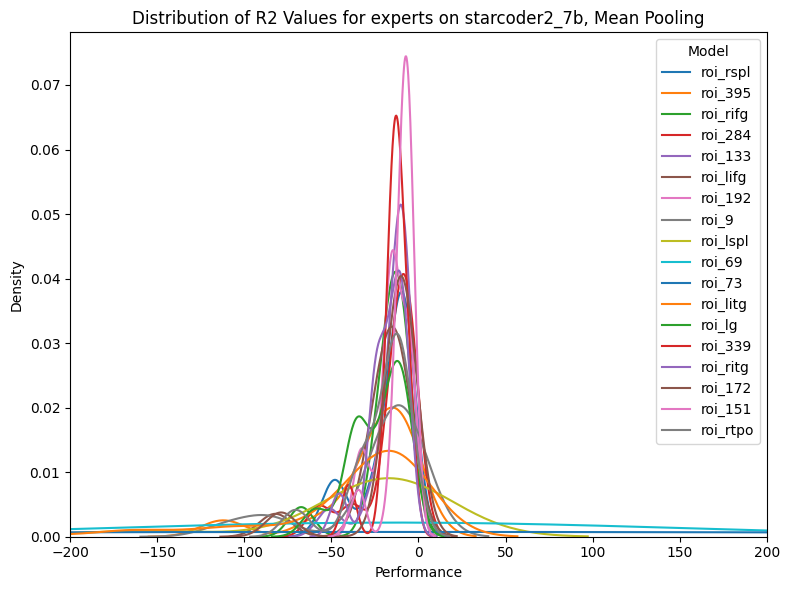

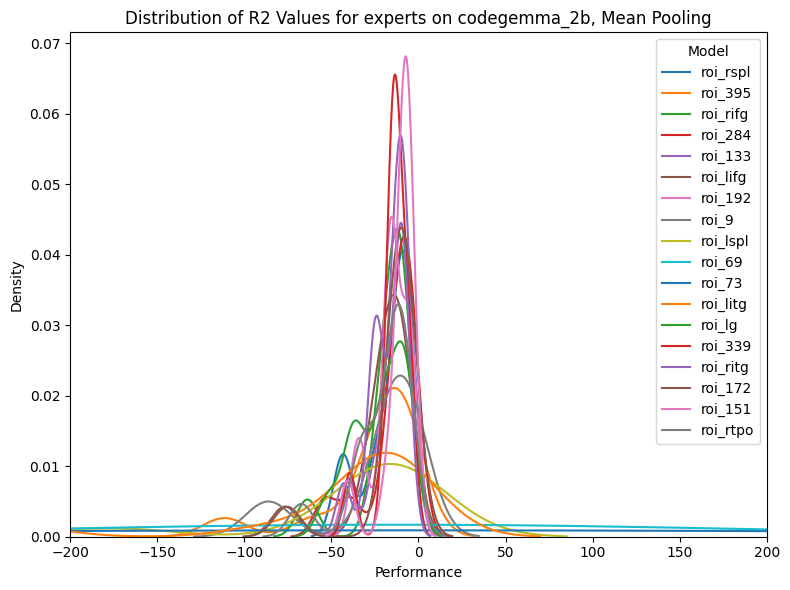

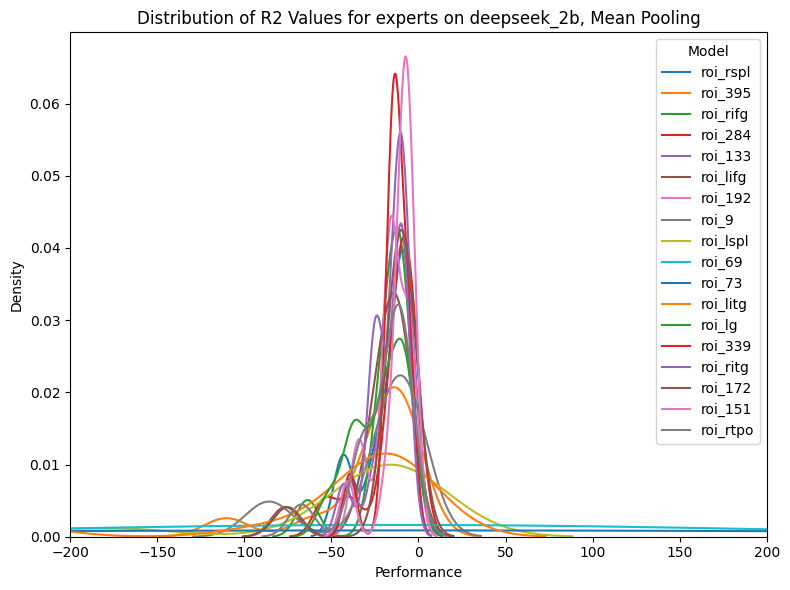

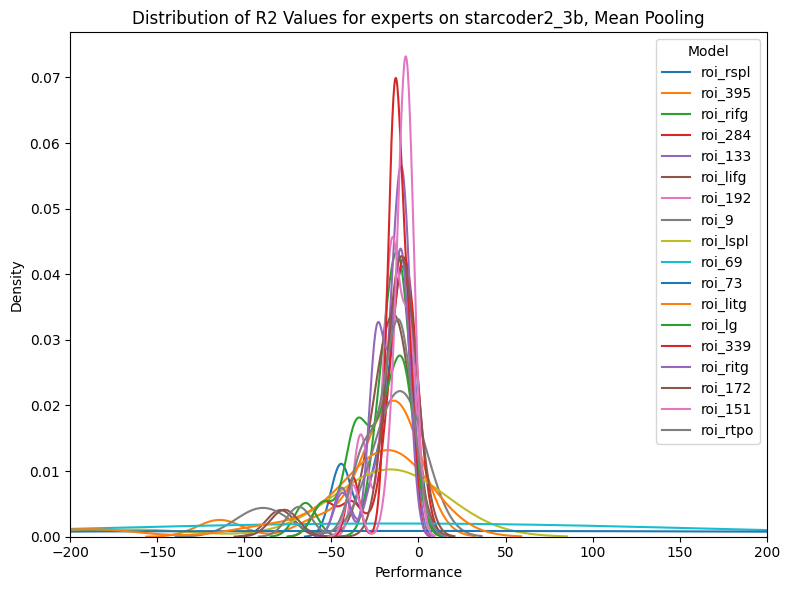

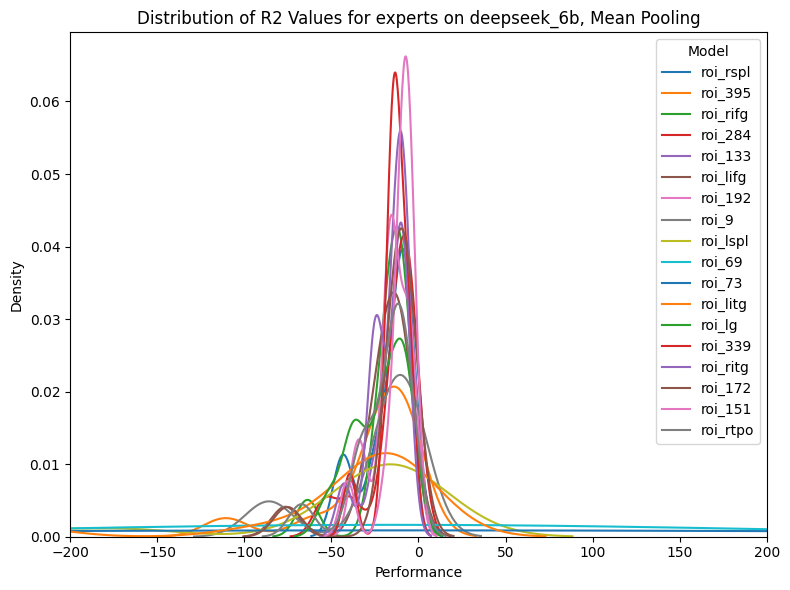

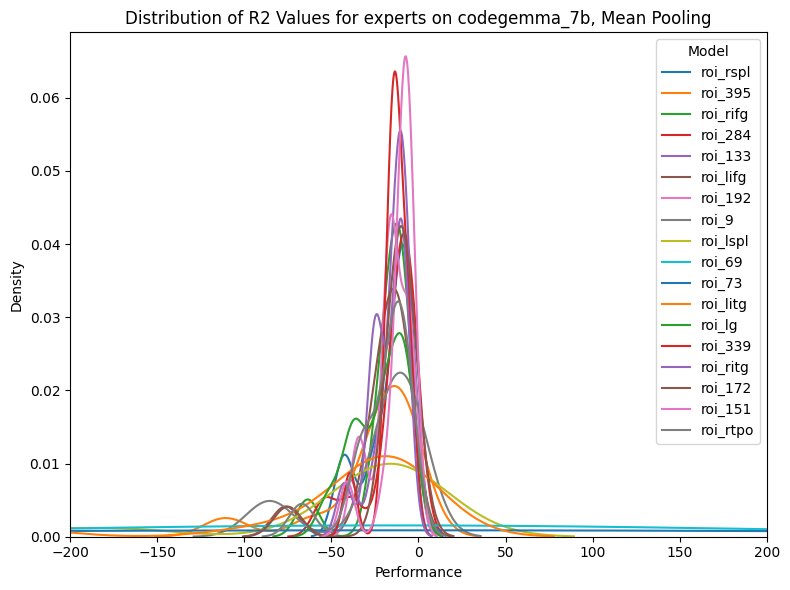

In [ ]:
# Make separate plot for each ROI
for group, model_data in expertise_roi_findings.items():

    for model, roi_dict in model_data.items():
        
        plt.figure(figsize=(8, 6))
        
        for roi, values in roi_dict.items():
            sns.kdeplot(values, label=roi, fill=False)
        
        plt.title(f"Distribution of R2 Values for {group} on {model}, Mean Pooling")
        plt.xlabel("Performance")
        plt.xlim([-200,200])
        plt.ylabel("Density")
        plt.legend(title="Model")
        plt.tight_layout()
        plt.show()

### ROI Alignment with Layers

In [ ]:
layer_findings = {}

layer_findings = {}
for participant, roi_dict in results_dict.items():
    for roi, model_dict in roi_dict.items():
        # model_dict, layer
        # layer_findings keys should be rois, with values being dictionaries for each model, and performance results therein
        for model, layer_dict in model_dict.items():

            print(model, len(layer_dict.keys()), layer_dict.keys())
            
        break
    break

            # there can be 5 or 6 layers, but they're not in order
            
            # if roi not in layer_findings.keys():
            #     layer_findings[roi] = {}

            # if model not in layer_findings[roi].keys():
            #     layer_findings[roi][model] = list(layer_dict.values())
            # else:
            #     layer_findings[roi][model].extend(list(layer_dict.values()))

starcoder2_7b 5 dict_keys(['layer_32.csv', 'layer_24.csv', 'layer_16.csv', 'layer_8.csv', 'layer_0.csv'])
codegemma_2b 6 dict_keys(['layer_12.csv', 'layer_4.csv', 'layer_16.csv', 'layer_18.csv', 'layer_8.csv', 'layer_0.csv'])
deepseek_2b 5 dict_keys(['layer_12.csv', 'layer_24.csv', 'layer_18.csv', 'layer_6.csv', 'layer_0.csv'])
starcoder2_3b 6 dict_keys(['layer_7.csv', 'layer_28.csv', 'layer_14.csv', 'layer_30.csv', 'layer_21.csv', 'layer_0.csv'])
deepseek_6b 5 dict_keys(['layer_32.csv', 'layer_24.csv', 'layer_16.csv', 'layer_8.csv', 'layer_0.csv'])
codegemma_7b 5 dict_keys(['layer_7.csv', 'layer_28.csv', 'layer_14.csv', 'layer_21.csv', 'layer_0.csv'])


In [ ]:


# I'd like to explore how each ROI does
# bar graph for each ROI across participants
# for each participant, take mean across layers?

# How each ROI compares to the different layers
# 

# Whether expertise has any effect
# split participants into experts and novices
# plot distributions
# 

'\nparticipant : {\n    ROI : {\n        model : mean_r2_value\n    }\n}\n\n'